# Cross-Reference Network Analysis of Kazakhstan's Legal Codes

**Paper 2: Cross-Code Comparative Analysis - Part 2**

This notebook analyzes citation and cross-reference patterns within and between Kazakhstan's legal codes:
- Criminal Code (УК)
- Administrative Code (КоАП)
- Civil Code (ГК)
- Labor Code (ТК)
- Tax Code (НК)

**Analysis dimensions:**
1. Citation extraction from article links
2. Within-code reference networks
3. Cross-code citation patterns
4. Network metrics (degree, PageRank, centrality)
5. Key hub articles identification
6. Network visualizations

## 1. Setup and Imports

In [2]:
import json
import pandas as pd
import numpy as np
from pathlib import Path
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Network analysis
import networkx as nx

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Configure matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['figure.figsize'] = (14, 10)
plt.rcParams['figure.dpi'] = 100

print("Setup complete!")

Setup complete!


## 2. Data Loading

In [3]:
# Define codes to analyze (from historical data - latest versions)
CODES = {
    "criminal": {
        "history_folder": "K1400000226_rus_ugolov",
        "doc_id": "K1400000226",
        "name_ru": "Уголовный кодекс",
        "name_en": "Criminal Code",
        "short": "УК"
    },
    "administrative": {
        "history_folder": "K1400000235_rus_adm",
        "doc_id": "K1400000235",
        "name_ru": "Кодекс об административных правонарушениях",
        "name_en": "Administrative Code",
        "short": "КоАП"
    },
    "civil": {
        "history_folder": "K940001000__rus_grazh",
        "doc_id": "K940001000_",
        "name_ru": "Гражданский кодекс",
        "name_en": "Civil Code",
        "short": "ГК"
    },
    "labor": {
        "history_folder": "K1500000414_rus_trud",
        "doc_id": "K1500000414",
        "name_ru": "Трудовой кодекс",
        "name_en": "Labor Code",
        "short": "ТК"
    },
    "tax": {
        "history_folder": "K2500000214_rus_nalog",
        "doc_id": "K2500000214",
        "name_ru": "Налоговый кодекс",
        "name_en": "Tax Code",
        "short": "НК"
    }
}

# Create reverse mapping from doc_id to code info
DOC_ID_TO_CODE = {v["doc_id"]: k for k, v in CODES.items()}

DATA_PATH = Path("../data/raw/by_history")

In [4]:
def load_code(code_key):
    """Load the latest version of a legal code from historical data."""
    history_folder = DATA_PATH / CODES[code_key]["history_folder"]
    
    # Read versions index to find the latest version
    index_path = history_folder / "versions_index.json"
    with open(index_path, "r", encoding="utf-8") as f:
        index = json.load(f)
    
    # Get the latest version (last entry in the versions array)
    latest_version = index["versions"][-1]
    version_file = history_folder / latest_version["filename"]
    
    # Load the version file
    with open(version_file, "r", encoding="utf-8") as f:
        data = json.load(f)
    
    return data["articles"]

# Load all codes
codes_data = {}
for code_key in CODES:
    codes_data[code_key] = load_code(code_key)
    print(f"{CODES[code_key]['short']}: {len(codes_data[code_key])} articles loaded")

УК: 502 articles loaded
КоАП: 1066 articles loaded
ГК: 425 articles loaded
ТК: 221 articles loaded
НК: 848 articles loaded


## 3. Citation Extraction

In [5]:
def extract_citations(data, source_code_key):
    """Extract all citations from a legal code.
    
    Returns:
        list of dicts with citation info:
        - source_code: code key of the source article
        - source_article_id: article_id of the source
        - source_article_title: title of the source article
        - target_doc_id: document ID of the target
        - target_anchor: anchor within the target document
        - link_text: text of the link
    """
    citations = []
    source_doc_id = CODES[source_code_key]["doc_id"]
    
    for article in data:
        article_id = article.get("article_id", "")
        article_title = article.get("article_title", "")
        
        # Collect links from paragraphs
        for paragraph in article.get("paragraphs", []):
            for link in paragraph.get("links", []):
                target_doc_id = link.get("target_doc_id", "")
                if target_doc_id:  # Only include links with valid target
                    citations.append({
                        "source_code": source_code_key,
                        "source_doc_id": source_doc_id,
                        "source_article_id": article_id,
                        "source_article_title": article_title,
                        "target_doc_id": target_doc_id,
                        "target_anchor": link.get("target_anchor", ""),
                        "link_text": link.get("text", "")
                    })
        
        # Also check article-level links
        for link in article.get("links", []):
            target_doc_id = link.get("target_doc_id", "")
            if target_doc_id:
                citations.append({
                    "source_code": source_code_key,
                    "source_doc_id": source_doc_id,
                    "source_article_id": article_id,
                    "source_article_title": article_title,
                    "target_doc_id": target_doc_id,
                    "target_anchor": link.get("target_anchor", ""),
                    "link_text": link.get("text", "")
                })
    
    return citations

# Extract citations from all codes
all_citations = []
for code_key in CODES:
    citations = extract_citations(codes_data[code_key], code_key)
    all_citations.extend(citations)
    print(f"{CODES[code_key]['short']}: {len(citations):,} citations extracted")

print(f"\nTotal citations: {len(all_citations):,}")

УК: 372 citations extracted
КоАП: 2,672 citations extracted
ГК: 149 citations extracted
ТК: 107 citations extracted
НК: 3,136 citations extracted

Total citations: 6,436


In [6]:
# Create citations DataFrame
citations_df = pd.DataFrame(all_citations)

# Classify citations as within-code or cross-code
citations_df["is_within_code"] = citations_df["source_doc_id"] == citations_df["target_doc_id"]

# Map target doc_id to code key (if known)
citations_df["target_code"] = citations_df["target_doc_id"].map(DOC_ID_TO_CODE)

print("Citation types:")
print(f"  Within-code: {citations_df['is_within_code'].sum():,}")
print(f"  Cross-code (to known codes): {(~citations_df['is_within_code'] & citations_df['target_code'].notna()).sum():,}")
print(f"  Cross-code (to other documents): {(~citations_df['is_within_code'] & citations_df['target_code'].isna()).sum():,}")

citations_df.head(10)

Citation types:
  Within-code: 5,923
  Cross-code (to known codes): 15
  Cross-code (to other documents): 498


,source_code,source_doc_id,source_article_id,source_article_title,target_doc_id,target_anchor,link_text,is_within_code,target_code
0,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K950001000_,z83,Конституции,False,NaN
1,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K950001000_,z0,Конституция,False,NaN
2,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K950001000_,z11,Конституции,False,NaN
3,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K1400000231,z1,Уголовно-процессуальный кодекс,False,NaN
4,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K1400000234,z1,Уголовно-исполнительный кодекс,False,NaN
5,criminal,K1400000226,z2,Статья 1. Уголовное законодательство Республик...,K1400000235,z2,Кодекс,False,administrative
6,criminal,K1400000226,z3002,"Статья 3. Разъяснение некоторых понятий, содер...",K1400000226,z754,198,True,criminal
7,criminal,K1400000226,z3002,"Статья 3. Разъяснение некоторых понятий, содер...",K1400000226,z759,199,True,criminal
8,criminal,K1400000226,z3002,"Статья 3. Разъяснение некоторых понятий, содер...",K1400000226,z772,202,True,criminal
9,criminal,K1400000226,z3002,"Статья 3. Разъяснение некоторых понятий, содер...",K1400000226,z820,214,True,criminal


## 4. Citation Statistics

In [7]:
# Citation statistics per code
citation_stats = []

for code_key in CODES:
    code_citations = citations_df[citations_df["source_code"] == code_key]
    within_code = code_citations[code_citations["is_within_code"]]
    cross_code = code_citations[~code_citations["is_within_code"]]
    
    # Count incoming citations (from other codes to this code)
    doc_id = CODES[code_key]["doc_id"]
    incoming = citations_df[
        (citations_df["target_doc_id"] == doc_id) & 
        (citations_df["source_doc_id"] != doc_id)
    ]
    
    citation_stats.append({
        "code": CODES[code_key]["short"],
        "total_citations": len(code_citations),
        "within_code": len(within_code),
        "cross_code_outgoing": len(cross_code),
        "cross_code_incoming": len(incoming),
        "articles_citing": code_citations["source_article_id"].nunique(),
        "avg_citations_per_article": len(code_citations) / len(codes_data[code_key])
    })

citation_stats_df = pd.DataFrame(citation_stats).set_index("code")
citation_stats_df

,total_citations,within_code,cross_code_outgoing,cross_code_incoming,articles_citing,avg_citations_per_article
code,,,,,,
УК,372,307,65,8,63,0.741036
КоАП,2672,2537,135,4,285,2.506567
ГК,149,93,56,3,86,0.350588
ТК,107,85,22,0,52,0.484163
НК,3136,2901,235,0,546,3.698113


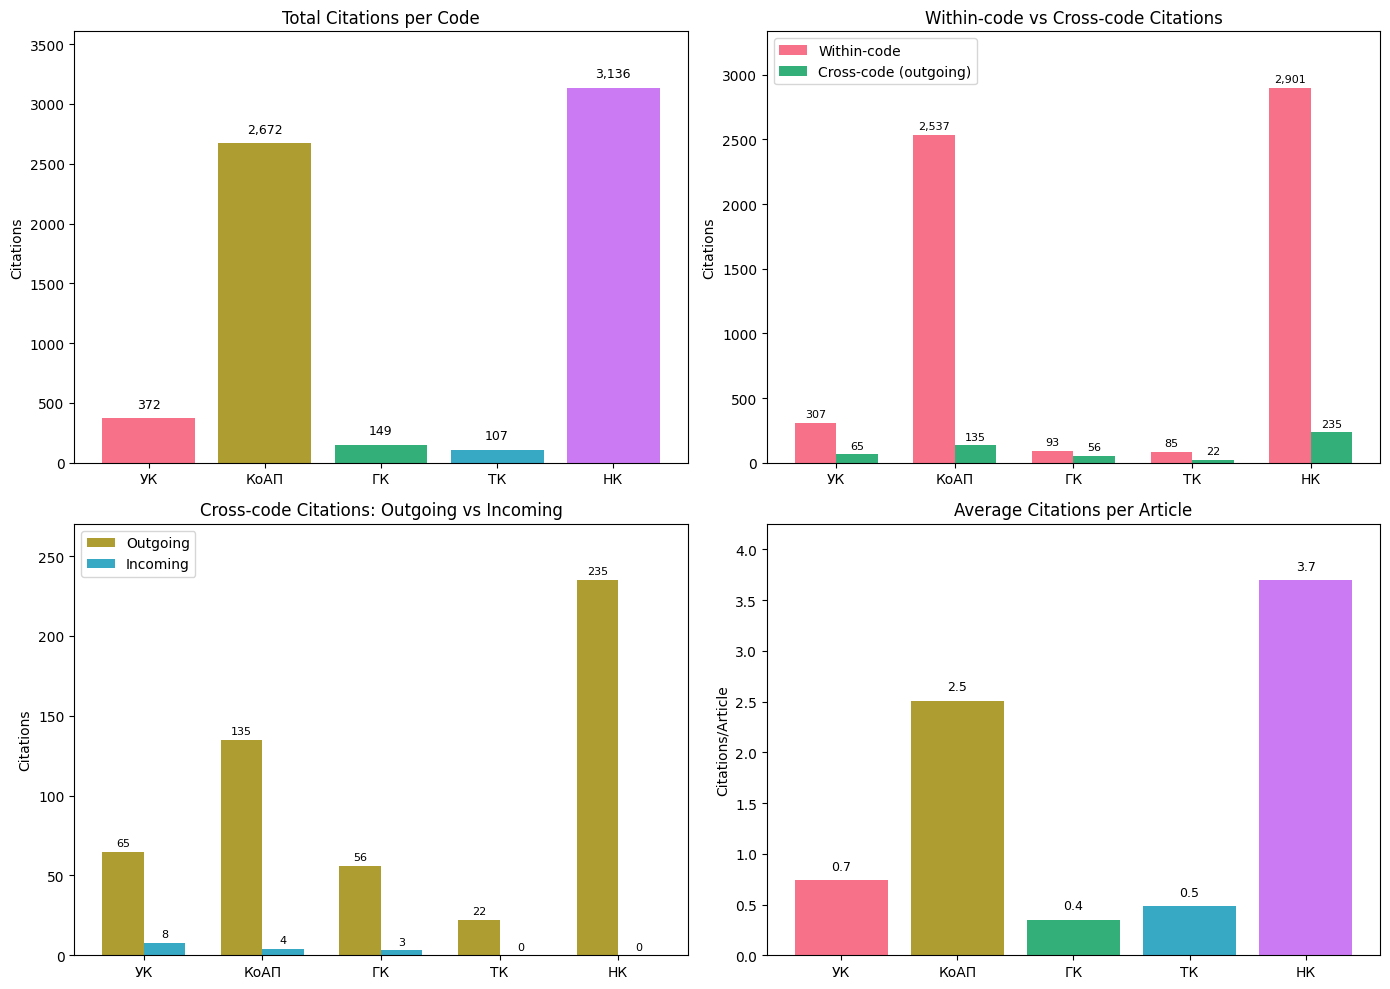

In [8]:
# Visualize citation statistics
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

codes_short = [CODES[k]["short"] for k in CODES]
colors = sns.color_palette("husl", len(CODES))

# Total citations
ax1 = axes[0, 0]
vals = citation_stats_df["total_citations"].values
bars = ax1.bar(codes_short, vals, color=colors)
ax1.set_title("Total Citations per Code", fontsize=12)
ax1.set_ylabel("Citations")
ax1.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
             f"{int(val):,}", ha='center', va='bottom', fontsize=9)

# Within vs Cross-code
ax2 = axes[0, 1]
x = np.arange(len(codes_short))
width = 0.35
within_vals = citation_stats_df["within_code"].values
cross_vals = citation_stats_df["cross_code_outgoing"].values
max_val2 = max(within_vals.max(), cross_vals.max())
bars1 = ax2.bar(x - width/2, within_vals, width, label="Within-code", color=colors[0])
bars2 = ax2.bar(x + width/2, cross_vals, width, label="Cross-code (outgoing)", color=colors[2])
ax2.set_xticks(x)
ax2.set_xticklabels(codes_short)
ax2.set_title("Within-code vs Cross-code Citations", fontsize=12)
ax2.set_ylabel("Citations")
ax2.set_ylim(0, max_val2 * 1.15)
ax2.legend()
# Add value labels
for bar, val in zip(bars1, within_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val2*0.01,
             f"{int(val):,}", ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, cross_vals):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val2*0.01,
             f"{int(val):,}", ha='center', va='bottom', fontsize=8)

# Incoming vs Outgoing cross-code
ax3 = axes[1, 0]
out_vals = citation_stats_df["cross_code_outgoing"].values
in_vals = citation_stats_df["cross_code_incoming"].values
max_val3 = max(out_vals.max(), in_vals.max())
bars3 = ax3.bar(x - width/2, out_vals, width, label="Outgoing", color=colors[1])
bars4 = ax3.bar(x + width/2, in_vals, width, label="Incoming", color=colors[3])
ax3.set_xticks(x)
ax3.set_xticklabels(codes_short)
ax3.set_title("Cross-code Citations: Outgoing vs Incoming", fontsize=12)
ax3.set_ylabel("Citations")
ax3.set_ylim(0, max_val3 * 1.15)
ax3.legend()
# Add value labels
for bar, val in zip(bars3, out_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val3*0.01,
             f"{int(val)}", ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars4, in_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max_val3*0.01,
             f"{int(val)}", ha='center', va='bottom', fontsize=8)

# Average citations per article
ax4 = axes[1, 1]
vals = citation_stats_df["avg_citations_per_article"].values
bars = ax4.bar(codes_short, vals, color=colors)
ax4.set_title("Average Citations per Article", fontsize=12)
ax4.set_ylabel("Citations/Article")
ax4.set_ylim(0, max(vals) * 1.15)
for bar, val in zip(bars, vals):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(vals)*0.02,
             f"{val:.1f}", ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig("../output/02/citation_statistics.png", dpi=150, bbox_inches='tight')
plt.show()

## 5. Cross-Code Citation Matrix

In [9]:
# Build cross-code citation matrix
# Rows = source code, Columns = target code
code_keys = list(CODES.keys())
n = len(code_keys)
cross_code_matrix = np.zeros((n, n))

for i, source_key in enumerate(code_keys):
    source_doc_id = CODES[source_key]["doc_id"]
    for j, target_key in enumerate(code_keys):
        target_doc_id = CODES[target_key]["doc_id"]
        # Count citations from source to target
        count = len(citations_df[
            (citations_df["source_doc_id"] == source_doc_id) &
            (citations_df["target_doc_id"] == target_doc_id)
        ])
        cross_code_matrix[i, j] = count

code_labels = [CODES[k]["short"] for k in code_keys]
cross_code_df = pd.DataFrame(cross_code_matrix, index=code_labels, columns=code_labels)
cross_code_df = cross_code_df.astype(int)

print("Cross-Code Citation Matrix (rows=source, columns=target):")
cross_code_df

Cross-Code Citation Matrix (rows=source, columns=target):


,УК,КоАП,ГК,ТК,НК
УК,307,1,0,0,0
КоАП,3,2537,0,0,0
ГК,0,0,93,0,0
ТК,0,0,0,85,0
НК,5,3,3,0,2901


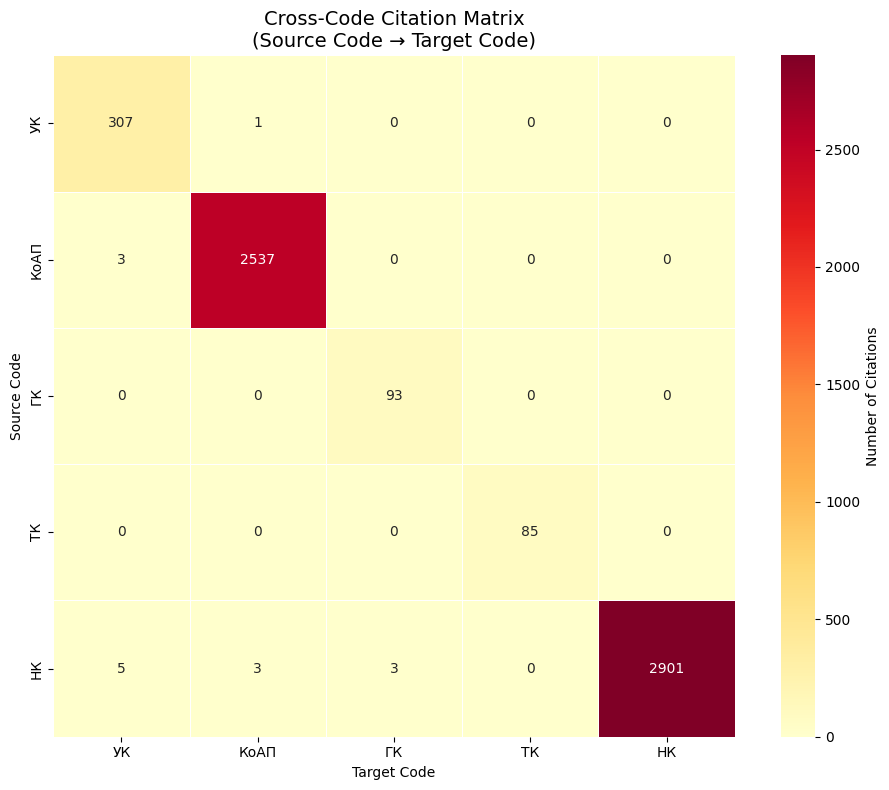

In [10]:
# Visualize cross-code citation matrix as heatmap
plt.figure(figsize=(10, 8))

# Mask diagonal for better visualization of cross-code citations
mask = np.eye(n, dtype=bool)

sns.heatmap(
    cross_code_df,
    annot=True,
    fmt="d",
    cmap="YlOrRd",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Number of Citations"}
)
plt.title("Cross-Code Citation Matrix\n(Source Code → Target Code)", fontsize=14)
plt.xlabel("Target Code")
plt.ylabel("Source Code")
plt.tight_layout()
plt.savefig("../output/02/cross_code_citation_matrix.png", dpi=150, bbox_inches='tight')
plt.show()

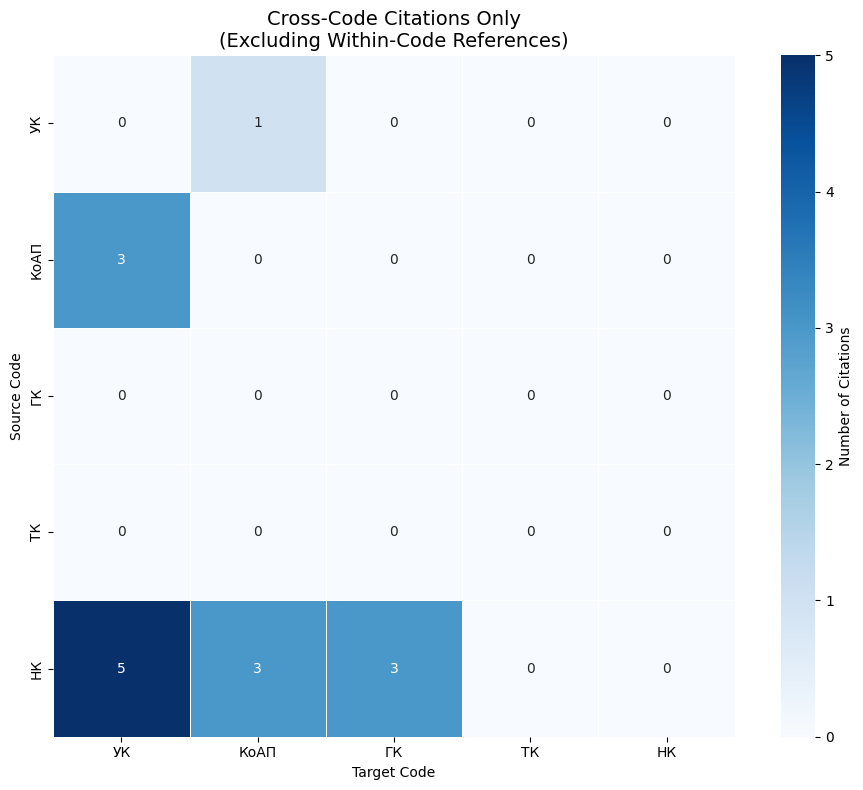

In [11]:
# Cross-code only (exclude within-code citations)
cross_only_matrix = cross_code_matrix.copy()
np.fill_diagonal(cross_only_matrix, 0)
cross_only_df = pd.DataFrame(cross_only_matrix, index=code_labels, columns=code_labels).astype(int)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cross_only_df,
    annot=True,
    fmt="d",
    cmap="Blues",
    square=True,
    linewidths=0.5,
    cbar_kws={"label": "Number of Citations"}
)
plt.title("Cross-Code Citations Only\n(Excluding Within-Code References)", fontsize=14)
plt.xlabel("Target Code")
plt.ylabel("Source Code")
plt.tight_layout()
plt.savefig("../output/02/cross_code_citations_only.png", dpi=150, bbox_inches='tight')
plt.show()

## 6. External Document References

In [14]:
# Analyze references to external documents (outside our 5 codes)
known_doc_ids = set(CODES[k]["doc_id"] for k in CODES)
external_refs = citations_df[~citations_df["target_doc_id"].isin(known_doc_ids)]

print(f"Total external references: {len(external_refs):,}")
print(f"Unique external documents: {external_refs['target_doc_id'].nunique()}")

# Group by target doc_id and collect all unique link texts and source codes
external_details = defaultdict(lambda: {"count": 0, "link_texts": set(), "source_codes": set()})

for _, row in external_refs.iterrows():
    doc_id = row["target_doc_id"]
    external_details[doc_id]["count"] += 1
    external_details[doc_id]["link_texts"].add(row["link_text"])
    external_details[doc_id]["source_codes"].add(row["source_code"])

# Sort by count and show top 25
sorted_docs = sorted(external_details.items(), key=lambda x: x[1]["count"], reverse=True)[:25]
external_counts = external_refs["target_doc_id"].value_counts()

print("\nTop 25 Most Referenced External Documents:")
print("=" * 90)

for doc_id, info in sorted_docs:
    count = info["count"]
    sources = ", ".join(sorted(CODES[s]["short"] for s in info["source_codes"]))
    link_texts = list(info["link_texts"])
    # Get the longest/most descriptive link text
    primary_text = max(link_texts, key=len) if link_texts else ""
    
    print(f"\n{doc_id} ({count} refs)")
    print(f"  Referenced by: {sources}")
    print(f"  Document name: {primary_text}")
    if len(link_texts) > 1:
        other_texts = [t for t in link_texts if t != primary_text][:4]
        print(f"  Other refs: {', '.join(other_texts)}")

Total external references: 498
Unique external documents: 146

Top 25 Most Referenced External Documents:

K1500000375 (40 refs)
  Referenced by: КоАП, НК
  Document name: Предпринимательским кодексом
  Other refs: пунктом 3, 5, 6, 8

K2300000224 (21 refs)
  Referenced by: НК, ТК
  Document name: Социального кодекса
  Other refs: статьей 207, Социальном кодексе, Социальным кодексом

K950001000_ (18 refs)
  Referenced by: ГК, КоАП, ТК, УК
  Document name: Конституцией
  Other refs: Конституции, статьи 55, пункте 5, пункте 3

Z950002444_ (17 refs)
  Referenced by: НК
  Document name: О банках и банковской деятельности в Республике Казахстан
  Other refs: статьей 5-1, О банках и банковской деятельности, статье 5-1

Z1900000292 (14 refs)
  Referenced by: КоАП, УК
  Document name: № 292-VІ
  Other refs: ст.2, ст. 2

K1400000231 (13 refs)
  Referenced by: КоАП, НК, ТК, УК
  Document name: Уголовно-процессуальным кодексом
  Other refs: статьи 36, статьи 405, статьи 35, статьей 165

Z150000040

## 7. Within-Code Citation Network Analysis

In [139]:
def build_within_code_network(code_key):
    """Build a directed graph of within-code citations."""
    G = nx.DiGraph()
    doc_id = CODES[code_key]["doc_id"]
    
    # Add all articles as nodes (skip if article_id is None or empty)
    for article in codes_data[code_key]:
        article_id = article.get("article_id")
        if article_id:  # Skip None or empty article_id
            article_title = article.get("article_title", "")
            G.add_node(article_id, title=article_title)  # Store full title
    
    # Add edges for within-code citations
    code_citations = citations_df[
        (citations_df["source_code"] == code_key) &
        (citations_df["is_within_code"])
    ]
    
    for _, row in code_citations.iterrows():
        source = row["source_article_id"]
        target_anchor = row["target_anchor"]
        
        # Skip if source is None
        if not source:
            continue
        
        # Find target article by anchor
        for article in codes_data[code_key]:
            if article.get("article_id") == target_anchor:
                target = target_anchor
                if target and source != target:
                    if G.has_edge(source, target):
                        G[source][target]["weight"] += 1
                    else:
                        G.add_edge(source, target, weight=1)
                break
    
    return G

# Build networks for each code
networks = {}
for code_key in CODES:
    G = build_within_code_network(code_key)
    networks[code_key] = G
    print(f"{CODES[code_key]['short']}: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges")

УК: 501 nodes, 218 edges
КоАП: 1062 nodes, 1758 edges
ГК: 424 nodes, 48 edges
ТК: 221 nodes, 20 edges
НК: 848 nodes, 669 edges


In [140]:
# Calculate network metrics for each code
network_metrics = []

for code_key in CODES:
    G = networks[code_key]
    
    if G.number_of_edges() > 0:
        # Basic metrics
        density = nx.density(G)
        
        # Degree statistics
        in_degrees = dict(G.in_degree())
        out_degrees = dict(G.out_degree())
        avg_in_degree = np.mean(list(in_degrees.values()))
        avg_out_degree = np.mean(list(out_degrees.values()))
        max_in_degree = max(in_degrees.values())
        max_out_degree = max(out_degrees.values())
        
        # Find hub articles (most cited and most citing)
        top_cited = max(in_degrees, key=in_degrees.get)
        top_citing = max(out_degrees, key=out_degrees.get)
    else:
        density = 0
        avg_in_degree = avg_out_degree = 0
        max_in_degree = max_out_degree = 0
        top_cited = top_citing = "N/A"
    
    network_metrics.append({
        "code": CODES[code_key]["short"],
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "density": density,
        "avg_in_degree": avg_in_degree,
        "avg_out_degree": avg_out_degree,
        "max_in_degree": max_in_degree,
        "max_out_degree": max_out_degree,
        "top_cited_article": top_cited,
        "top_citing_article": top_citing
    })

network_metrics_df = pd.DataFrame(network_metrics).set_index("code")
network_metrics_df

,nodes,edges,density,avg_in_degree,avg_out_degree,max_in_degree,max_out_degree,top_cited_article,top_citing_article
code,,,,,,,,,
УК,501,218,0.000870,0.435130,0.435130,3,140,z170,z3002
КоАП,1062,1758,0.001560,1.655367,1.655367,14,214,z2449,z2792
ГК,424,48,0.000268,0.113208,0.113208,4,5,z458,z508
ТК,221,20,0.000411,0.090498,0.090498,3,5,z109,z138
НК,848,669,0.000931,0.788915,0.788915,9,12,z2051,z11564


In [141]:
# PageRank analysis for each code
print("Top 10 Most Important Articles by PageRank (per code):")
print("="*70)

pagerank_results = {}

for code_key in CODES:
    G = networks[code_key]
    
    if G.number_of_edges() > 0:
        # Calculate PageRank
        pr = nx.pagerank(G, alpha=0.85)
        pagerank_results[code_key] = pr
        
        # Get top 10
        top_pr = sorted(pr.items(), key=lambda x: x[1], reverse=True)[:10]
        
        print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}):")
        for article_id, score in top_pr:
            # Get full article title
            title = G.nodes[article_id].get("title", "Unknown")
            print(f"  {article_id}: {score:.6f} - {title}")
    else:
        print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}): No edges")

Top 10 Most Important Articles by PageRank (per code):

Criminal Code (УК):
  z402: 0.006724 - Статья 91. Основания применения принудительных мер медицинского характера
  z170: 0.006573 - Статья 44. Ограничение свободы
  z304: 0.005399 - Статья 72. Условно-досрочное освобождение от отбывания наказания
  z297: 0.005019 - Статья 71. Освобождение от уголовной ответственности в связи с истечением срока давности
  z1367: 0.004376 - Статья 366. Получение взятки
  z313: 0.004157 - Статья 73. Замена неотбытой части наказания более мягким видом наказания либо сокращение срока назначенного наказания
  z356: 0.003922 - Статья 81. Виды наказаний, назначаемых несовершеннолетним
  z1060: 0.003525 - Статья 286. Контрабанда изъятых из обращения предметов или предметов, обращение которых ограничено
  z35: 0.003504 - Статья 9. Выдача лиц, совершивших уголовное правонарушение
  z135: 0.003504 - Статья 34. Крайняя необходимость

Administrative Code (КоАП):
  z2792: 0.009126 - Статья 804. Должностные лица,

## 8. Cross-Code Citation Network

In [142]:
# Build cross-code network (codes as nodes)
G_cross = nx.DiGraph()

# Add code nodes
for code_key in CODES:
    G_cross.add_node(
        CODES[code_key]["short"],
        name=CODES[code_key]["name_en"],
        articles=len(codes_data[code_key])
    )

# Add edges from cross-code citation matrix
for i, source_key in enumerate(code_keys):
    for j, target_key in enumerate(code_keys):
        if i != j:  # Exclude self-loops
            weight = int(cross_code_matrix[i, j])
            if weight > 0:
                G_cross.add_edge(
                    CODES[source_key]["short"],
                    CODES[target_key]["short"],
                    weight=weight
                )

print(f"Cross-code network: {G_cross.number_of_nodes()} codes, {G_cross.number_of_edges()} connections")

Cross-code network: 5 codes, 5 connections


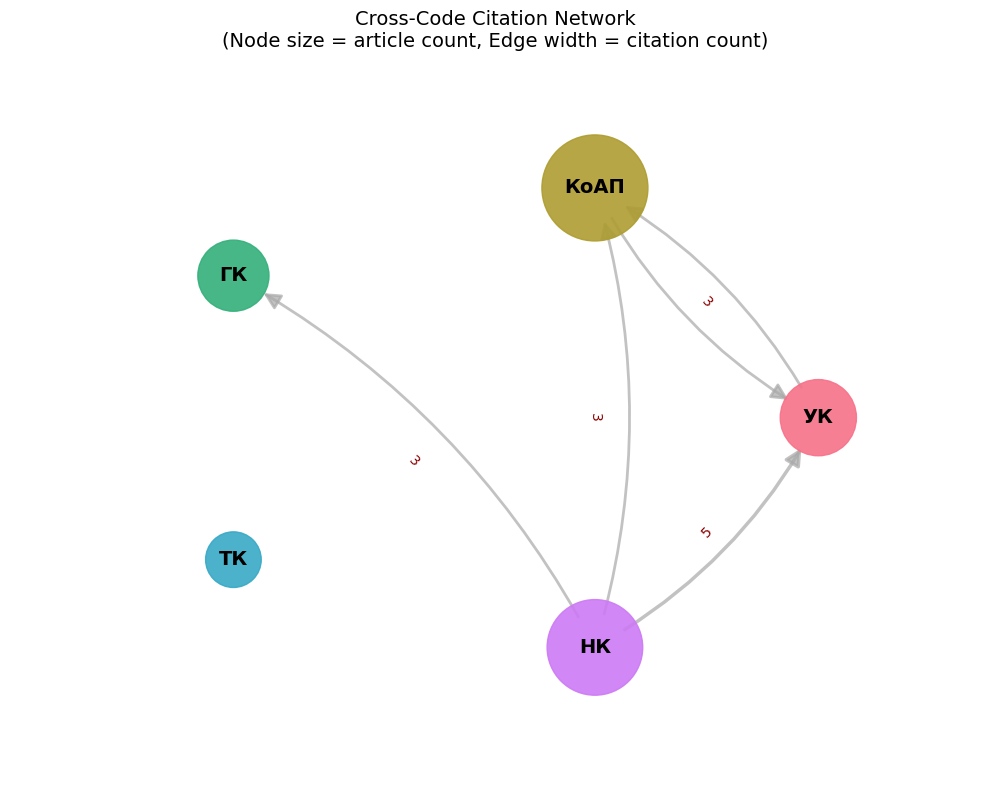

In [143]:
# Visualize cross-code citation network
fig, ax = plt.subplots(figsize=(10, 8))

# Position nodes in a tighter circle (scale parameter)
pos = nx.circular_layout(G_cross, scale=0.4)

# Node sizes based on number of articles (larger scaling)
node_sizes = [G_cross.nodes[n]["articles"] * 5 + 500 for n in G_cross.nodes()]

# Edge widths - use better scaling with minimum visibility
edge_weights = [max(2, G_cross[u][v]["weight"] * 0.5) for u, v in G_cross.edges()]

# Get colors
node_colors = sns.color_palette("husl", len(CODES))

# Draw nodes
nx.draw_networkx_nodes(G_cross, pos, node_size=node_sizes, 
                       node_color=node_colors, alpha=0.9, ax=ax)

# Draw labels
nx.draw_networkx_labels(G_cross, pos, font_size=14, font_weight='bold', ax=ax)

# Draw edges with better visibility
nx.draw_networkx_edges(G_cross, pos, width=edge_weights, alpha=0.7,
                       edge_color='darkgray', arrows=True, arrowsize=25,
                       arrowstyle='-|>', connectionstyle="arc3,rad=0.15",
                       min_source_margin=25, min_target_margin=25, ax=ax)

# Add edge labels
edge_labels = {(u, v): G_cross[u][v]["weight"] for u, v in G_cross.edges()}
nx.draw_networkx_edge_labels(G_cross, pos, edge_labels, font_size=10, 
                             font_color='darkred', ax=ax)

ax.set_title("Cross-Code Citation Network\n(Node size = article count, Edge width = citation count)", fontsize=14)
ax.axis('off')
ax.set_xlim(-0.6, 0.6)
ax.set_ylim(-0.6, 0.6)

plt.tight_layout()
plt.savefig("../output/02/cross_code_network.png", dpi=150, bbox_inches='tight')
plt.show()

## 9. Key Hub Articles Identification

In [144]:
# Find the most cited articles across all codes
print("Most Cited Articles (by incoming within-code references):")
print("="*70)

all_hub_articles = []

for code_key in CODES:
    G = networks[code_key]
    
    if G.number_of_edges() > 0:
        in_degrees = dict(G.in_degree())
        top_cited = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}):")
        for article_id, degree in top_cited:
            if degree > 0:
                title = G.nodes[article_id].get("title", "Unknown")
                print(f"  {article_id}: {degree} citations - {title}")
                all_hub_articles.append({
                    "code": CODES[code_key]["short"],
                    "article_id": article_id,
                    "title": title,
                    "in_degree": degree
                })

Most Cited Articles (by incoming within-code references):

Criminal Code (УК):
  z170: 3 citations - Статья 44. Ограничение свободы
  z402: 3 citations - Статья 91. Основания применения принудительных мер медицинского характера
  z1367: 3 citations - Статья 366. Получение взятки
  z297: 2 citations - Статья 71. Освобождение от уголовной ответственности в связи с истечением срока давности
  z432: 2 citations - Статья 99. Убийство

Administrative Code (КоАП):
  z2449: 14 citations - Статья 744. Лицо, в отношении которого ведется производство по делу об административном правонарушении
  z2435: 13 citations - Статья 741. Обстоятельства, исключающие производство по делу об административном правонарушении
  z2460: 13 citations - Статья 746. Законные представители физического лица
  z836: 12 citations - Статья 230. Нарушение законодательства Республики Казахстан об обязательном страховании
  z2455: 12 citations - Статья 745. Потерпевший

Civil Code (ГК):
  z458: 4 citations - Статья 218. Разд

In [145]:
# Find articles that cite the most other articles
print("Most Citing Articles (by outgoing references):")
print("="*70)

for code_key in CODES:
    G = networks[code_key]
    
    if G.number_of_edges() > 0:
        out_degrees = dict(G.out_degree())
        top_citing = sorted(out_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
        
        print(f"\n{CODES[code_key]['name_en']} ({CODES[code_key]['short']}):")
        for article_id, degree in top_citing:
            if degree > 0:
                title = G.nodes[article_id].get("title", "Unknown")
                print(f"  {article_id}: {degree} outgoing refs - {title}")

Most Citing Articles (by outgoing references):

Criminal Code (УК):
  z3002: 140 outgoing refs - Статья 3. Разъяснение некоторых понятий, содержащихся в настоящем Кодексе
  z3029: 30 outgoing refs - Статья 15. Лица, подлежащие уголовной ответственности
  z179: 5 outgoing refs - Статья 46. Лишение свободы
  z201: 5 outgoing refs - Статья 50. Лишение права занимать определенную должность или заниматься определенной деятельностью
  z222: 5 outgoing refs - Статья 55. Назначение более мягкого наказания, чем предусмотрено за данное уголовное правонарушение

Administrative Code (КоАП):
  z2792: 214 outgoing refs - Статья 804. Должностные лица, имеющие право составлять протоколы об административных правонарушениях
  z2227: 203 outgoing refs - Статья 684. Суды
  z2233: 105 outgoing refs - Статья 685. Органы внутренних дел (полиция)
  z2356: 97 outgoing refs - Статья 720. Органы государственных доходов
  z2796: 68 outgoing refs - Статья 805. Возбуждение производства по делу об административном п

## 10. Network Visualization (Criminal Code Sample)

In [ ]:
# Visualize a sample network (Criminal Code - typically has good structure)
# Only show nodes with at least one connection

code_to_viz = "criminal"
G = networks[code_to_viz]

# Filter to connected nodes only
connected_nodes = [n for n in G.nodes() if G.degree(n) > 0]
G_connected = G.subgraph(connected_nodes).copy()

print(f"Visualizing {CODES[code_to_viz]['name_en']} network")
print(f"Connected subgraph: {G_connected.number_of_nodes()} nodes, {G_connected.number_of_edges()} edges")

if G_connected.number_of_nodes() > 0:
    plt.figure(figsize=(16, 12))
    
    # Use spring layout for better visualization
    pos = nx.spring_layout(G_connected, k=2, iterations=50, seed=42)
    
    # Node sizes based on in-degree (more cited = larger)
    in_degrees = dict(G_connected.in_degree())
    node_sizes = [max(100, in_degrees[n] * 50) for n in G_connected.nodes()]
    
    # Node colors based on out-degree (more citing = darker)
    out_degrees = dict(G_connected.out_degree())
    node_colors = [out_degrees[n] for n in G_connected.nodes()]
    
    # Draw
    nx.draw_networkx_nodes(G_connected, pos, node_size=node_sizes,
                           node_color=node_colors, cmap=plt.cm.YlOrRd, alpha=0.8)
    nx.draw_networkx_edges(G_connected, pos, alpha=0.3, arrows=True, arrowsize=10)
    
    # Label only high-degree nodes
    high_degree_nodes = {n: n for n in G_connected.nodes() if G_connected.degree(n) >= 3}
    nx.draw_networkx_labels(G_connected, pos, high_degree_nodes, font_size=8)
    
    plt.title(f"{CODES[code_to_viz]['name_en']} - Citation Network\n(Node size = citations received, Color = citations made)",
              fontsize=14)
    plt.axis('off')
    plt.tight_layout()
    plt.savefig(f"../output/02/{code_to_viz}_citation_network.png", dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("No connected nodes to visualize")

In [147]:
# Export results
citations_df.to_csv("../output/02/all_citations.csv", index=False)
citation_stats_df.to_csv("../output/02/citation_statistics.csv")
cross_code_df.to_csv("../output/02/cross_code_citation_matrix.csv")
network_metrics_df.to_csv("../output/02/network_metrics.csv")

print("Exported to output/02/:")
print("  - all_citations.csv")
print("  - citation_statistics.csv")
print("  - cross_code_citation_matrix.csv")
print("  - network_metrics.csv")

Exported to output/02/:
  - all_citations.csv
  - citation_statistics.csv
  - cross_code_citation_matrix.csv
  - network_metrics.csv


## 11. Summary and Export

In [148]:
print("="*70)
print("KEY FINDINGS - Cross-Reference Network Analysis")
print("="*70)

# Calculate actual values from the data
total_citations = len(citations_df)
within_code_count = citations_df['is_within_code'].sum()
cross_code_known = (~citations_df['is_within_code'] & citations_df['target_code'].notna()).sum()
cross_code_external = (~citations_df['is_within_code'] & citations_df['target_code'].isna()).sum()
within_pct = within_code_count / total_citations * 100

print("\n" + "="*70)
print("1. CITATION VOLUME OVERVIEW")
print("="*70)
print(f"""
   TOTAL CITATIONS: {total_citations:,} extracted from 5 legal codes
   
   CITATION DISTRIBUTION:
   • Within-code citations: {within_code_count:,} ({within_pct:.1f}%) - codes mostly self-referential
   • Cross-code citations: {total_citations - within_code_count:,} ({100-within_pct:.1f}%)
     - To known codes (5 analyzed): only {cross_code_known} citations
     - To external documents: {cross_code_external} citations ({external_refs['target_doc_id'].nunique()} unique docs)
   
   KEY INSIGHT: Legal codes are highly self-contained with minimal
   cross-referencing between codes. External references primarily to
   amendment laws and related legislation.
""")

print("="*70)
print("2. CITATIONS BY CODE - DENSITY ANALYSIS")
print("="*70)
print(f"""
   CODE          TOTAL    AVG/ARTICLE   ARTICLES CITING
   ─────────────────────────────────────────────────────""")
for code_key in CODES:
    short = CODES[code_key]['short']
    total = citation_stats_df.loc[short, 'total_citations']
    avg = citation_stats_df.loc[short, 'avg_citations_per_article']
    citing = citation_stats_df.loc[short, 'articles_citing']
    n_articles = len(codes_data[code_key])
    pct = citing / n_articles * 100
    print(f"   {short:12} {total:>5,}    {avg:.2f}          {citing} ({pct:.0f}% of articles)")

print(f"""
   KEY INSIGHT: Tax Code is most interconnected ({citation_stats_df.loc['НК', 'avg_citations_per_article']:.1f} citations/article),
   while Civil Code is most self-contained ({citation_stats_df.loc['ГК', 'avg_citations_per_article']:.2f} citations/article).
   Tax and Administrative codes contain majority of all citations.
""")

print("="*70)
print("3. CROSS-CODE CITATION PATTERNS")
print("="*70)
print(f"""
   CROSS-CODE CITATION MATRIX (non-zero pairs only):
   
   SOURCE → TARGET    CITATIONS
   ─────────────────────────────""")
# Print non-zero cross-code citations
for i, source_key in enumerate(code_keys):
    for j, target_key in enumerate(code_keys):
        if i != j and cross_code_matrix[i, j] > 0:
            src = CODES[source_key]['short']
            tgt = CODES[target_key]['short']
            count = int(cross_code_matrix[i, j])
            print(f"   {src} → {tgt}              {count}")

# Find most referenced and most referencing codes
incoming_totals = {CODES[k]['short']: citation_stats_df.loc[CODES[k]['short'], 'cross_code_incoming'] for k in CODES}
outgoing_totals = {CODES[k]['short']: citation_stats_df.loc[CODES[k]['short'], 'cross_code_outgoing'] for k in CODES}
most_referenced = max(incoming_totals, key=incoming_totals.get)
most_referencing = max(outgoing_totals, key=outgoing_totals.get)

print(f"""
   ISOLATED CODES:
   • Civil Code (ГК): NO outgoing cross-code citations to other 5 codes
   • Labor Code (ТК): NO outgoing cross-code citations to other 5 codes
   
   MOST REFERENCED CODE: {most_referenced} - {incoming_totals[most_referenced]} incoming citations
   MOST REFERENCING CODE: {most_referencing} - {outgoing_totals[most_referencing]} outgoing citations
   
   KEY INSIGHT: Tax Code acts as a "hub" connecting to other codes.
   Civil and Labor codes operate in relative isolation from other codes.
""")

print("="*70)
print("4. NETWORK STRUCTURE METRICS")
print("="*70)
print(f"""
   CODE     NODES   EDGES    DENSITY    AVG DEG   MAX IN   MAX OUT
   ─────────────────────────────────────────────────────────────────""")
for code_key in CODES:
    short = CODES[code_key]['short']
    m = network_metrics_df.loc[short]
    print(f"   {short:6}  {int(m['nodes']):>5}   {int(m['edges']):>5}    {m['density']:.5f}    {m['avg_in_degree']:.2f}     {int(m['max_in_degree']):>3}      {int(m['max_out_degree']):>3}")

print(f"""
   NETWORK CHARACTERISTICS:
   • All networks are EXTREMELY SPARSE (density < 0.2%)
   • КоАП has highest connectivity ({int(network_metrics_df.loc['КоАП', 'edges']):,} edges, avg degree {network_metrics_df.loc['КоАП', 'avg_in_degree']:.2f})
   • ТК has lowest connectivity ({int(network_metrics_df.loc['ТК', 'edges'])} edges, avg degree {network_metrics_df.loc['ТК', 'avg_in_degree']:.2f})
   • High max_out values indicate "index" articles (definitions, jurisdictions)
""")

print("="*70)
print("5. HUB ARTICLES - MOST CITED (AUTHORITIES)")
print("="*70)
print(f"""
   These articles are referenced most frequently within their codes:
   
   КоАП ({int(network_metrics_df.loc['КоАП', 'max_in_degree'])} citations max):
   • Article 744 - "Лицо, в отношении которого ведется производство"
     (Person under administrative proceedings - procedural cornerstone)
   
   НК ({int(network_metrics_df.loc['НК', 'max_in_degree'])} citations max):
   • Article 122 - Tax refund/credit procedures
   • Article 287 - Deductible expenses exclusions
   • Article 345 - Corporate income tax calculation
   
   ГК ({int(network_metrics_df.loc['ГК', 'max_in_degree'])} citations max):
   • Article 218 - Division of shared property
   
   УК ({int(network_metrics_df.loc['УК', 'max_in_degree'])} citations max):
   • Article 44 - Restriction of liberty
   • Article 91 - Compulsory medical measures
   • Article 366 - Bribery
   
   ТК ({int(network_metrics_df.loc['ТК', 'max_in_degree'])} citations max):
   • Article 109 - Holiday/weekend work compensation
""")

print("="*70)
print("6. INDEX ARTICLES - MOST CITING (CONNECTORS)")
print("="*70)
print(f"""
   These articles reference many other articles (structural hubs):
   
   КоАП {network_metrics_df.loc['КоАП', 'top_citing_article']} ({int(network_metrics_df.loc['КоАП', 'max_out_degree'])} outgoing refs):
   • Article 804 - "Должностные лица, имеющие право составлять протоколы"
     (Officials authorized to file administrative protocols)
     → References nearly every offense article
   
   УК {network_metrics_df.loc['УК', 'top_citing_article']} ({int(network_metrics_df.loc['УК', 'max_out_degree'])} outgoing refs):
   • Article 3 - "Разъяснение некоторых понятий"
     (Definitions and terminology explanations)
     → Central glossary article referencing crime definitions
   
   KEY INSIGHT: "Index" articles (definitions, jurisdictions, authorities)
   serve as navigation hubs within legal codes.
""")

print("="*70)
print("7. PAGERANK - MOST IMPORTANT BY NETWORK POSITION")
print("="*70)
print(f"""
   PageRank identifies structurally important articles (not just most cited):
   
   CODE   ARTICLE   PAGERANK   TITLE
   ─────────────────────────────────────────────────────────────────────""")
# Get top PageRank article from each code
for code_key in CODES:
    short = CODES[code_key]['short']
    if code_key in pagerank_results:
        pr = pagerank_results[code_key]
        top_article = max(pr, key=pr.get)
        top_score = pr[top_article]
        title = networks[code_key].nodes[top_article].get('title', 'Unknown')[:45]
        print(f"   {short:6} {top_article:9} {top_score:.4f}     {title}...")

print(f"""
   KEY INSIGHT: Labor Code's Article 109 has HIGHEST PageRank despite
   ТК having fewest edges - indicates critical structural position.
""")

print("="*70)
print("8. EXTERNAL DOCUMENT REFERENCES")
print("="*70)
n_external = len(external_refs)
n_unique_external = external_refs['target_doc_id'].nunique()
print(f"""
   Total external references: {n_external} (to {n_unique_external} unique documents)
   
   TOP REFERENCED EXTERNAL DOCUMENTS:
   ─────────────────────────────────────────────────────────────────────""")
for doc_id, count in external_counts.head(6).items():
    sample_text = external_refs[external_refs["target_doc_id"] == doc_id]["link_text"].iloc[0][:40]
    print(f"   {doc_id}    {count:>2} refs   {sample_text}...")

print(f"""
   KEY INSIGHT: Most external references are to amendment laws (Z-prefix)
   and related codes (K-prefix). Constitution referenced multiple times.
""")

print("="*70)
print("9. KEY INSIGHTS FOR LEGAL KNOWLEDGE GRAPHS")
print("="*70)
print(f"""
   STRUCTURAL PATTERNS:
   • Legal codes are highly MODULAR - {within_pct:.0f}% citations are internal
   • Tax Code is the primary BRIDGE between codes
   • Civil & Labor codes are ISOLATED from other codes
   
   IMPORTANT ARTICLE TYPES:
   • "Definition" articles (УК Art.3, etc.) - high out-degree
   • "Jurisdiction" articles (КоАП Art.804) - high out-degree
   • "Procedural" articles (КоАП Art.744) - high in-degree
   
   NETWORK SPARSITY:
   • All codes have density < 0.2% (very sparse networks)
   • Most articles have 0-1 connections
   • Few "super-connector" articles dominate citation patterns
   
   IMPLICATIONS FOR NLP/AI:
   • Cross-code reasoning requires explicit linking
   • Index articles are key for navigation/search
   • External document resolution needed for full context
   • Total corpus: {total_citations:,} citations across {sum(len(codes_data[k]) for k in CODES):,} articles
""")

print("="*70)

KEY FINDINGS - Cross-Reference Network Analysis

1. CITATION VOLUME OVERVIEW

   TOTAL CITATIONS: 6,436 extracted from 5 legal codes

   CITATION DISTRIBUTION:
   • Within-code citations: 5,923 (92.0%) - codes mostly self-referential
   • Cross-code citations: 513 (8.0%)
     - To known codes (5 analyzed): only 15 citations
     - To external documents: 498 citations (146 unique docs)

   KEY INSIGHT: Legal codes are highly self-contained with minimal
   cross-referencing between codes. External references primarily to
   amendment laws and related legislation.

2. CITATIONS BY CODE - DENSITY ANALYSIS

   CODE          TOTAL    AVG/ARTICLE   ARTICLES CITING
   ─────────────────────────────────────────────────────
   УК             372    0.74          63 (13% of articles)
   КоАП         2,672    2.51          285 (27% of articles)
   ГК             149    0.35          86 (20% of articles)
   ТК             107    0.48          52 (24% of articles)
   НК           3,136    3.70       